# DBSCAN on 12D MFCC Features

Recommendation for this project: start with **segment-level pooled vectors**, not raw frames and not utterance-level vectors.

Why:
- **Raw frames** are too local and heavily autocorrelated. You have about **1.42M frames**, many adjacent frames are nearly identical, and DBSCAN will mostly respond to local density, silence dominance, and speaker/context effects rather than phoneme-like units.
- **Utterance-level vectors** are too coarse for phoneme analysis. They mix many phones together, so clusters become more about sentence or speaker characteristics than speech units.
- **Segment-level vectors** are the practical middle ground here. You already have phone-aligned segment annotations, which means we can build one vector per labeled segment, cluster those, and later compare cluster assignments against phoneme labels.

Baseline representation: use the 12D features from `train_dim12.json`, and for each labeled phone segment start with a simple **mean-pooled 12D vector**. If that proves too weak, the next extension should be `[segment_mean, segment_std, log_duration]`, but not yet.


In [3]:
import json
from collections import Counter

import numpy as np

with open("train_dim12.json", "r") as f:
    data = json.load(f)

first_key = next(iter(data))
first_entry = data[first_key]
first_feat = np.asarray(first_entry["features"], dtype=np.float32)

num_utts = len(data)
total_frames = sum(len(utt["features"]) for utt in data.values())
frame_lengths = np.array([len(utt["features"]) for utt in data.values()])

print("num utterances:", num_utts)
print("total frames:", total_frames)
print("first key:", first_key)
print("fields:", sorted(first_entry.keys()))
print("first feature shape:", first_feat.shape)
print("frame length min / mean / max:", frame_lengths.min(), round(frame_lengths.mean(), 2), frame_lengths.max())

label_counter = Counter()
end_eq_T = 0
end_eq_Tm1 = 0
end_lt_Tm1 = 0

for utt in data.values():
    label_counter.update(utt["phn_wise_segment"])
    T = len(utt["features"])
    last_end = utt["phn_transcript"][-1][2]
    if last_end == T:
        end_eq_T += 1
    elif last_end == T - 1:
        end_eq_Tm1 += 1
    elif last_end < T - 1:
        end_lt_Tm1 += 1

print("total labeled segments:", sum(label_counter.values()))
print("unique phoneme labels:", len(label_counter))
print("top 10 phoneme labels:", label_counter.most_common(10))
print("utterances with last segment ending at T:", end_eq_T)
print("utterances with last segment ending at T-1:", end_eq_Tm1)
print("utterances with unlabeled trailing frames:", end_lt_Tm1)


num utterances: 4620
total frames: 1421707
first key: FEXM0_SX291
fields: ['feat_shape', 'features', 'no_segments', 'phn_transcript', 'phn_wise_segment', 'segment_boundary']
first feature shape: (349, 12)
frame length min / mean / max: 92 307.73 779
total labeled segments: 177080
unique phoneme labels: 39
top 10 phoneme labels: [('sil', 39467), ('ih', 13693), ('n', 8762), ('s', 7475), ('iy', 6953), ('l', 6752), ('r', 6539), ('ah', 6291), ('aa', 6004), ('er', 5453)]
utterances with last segment ending at T: 829
utterances with last segment ending at T-1: 3465
utterances with unlabeled trailing frames: 326


## Step 1

Build a clean **segment-level dataset** from `phn_transcript`.

Important normalization rule:
- For most utterances, the transcript spans are internally consistent.
- Some utterances end at `T-1` instead of `T`; for the **final segment only**, treat `end == T-1` as `T`.
- Some utterances have unlabeled trailing frames; do **not** force them into a segment. We will ignore that tail for now.

This gives us one inspectable example per labeled segment, which is the right place to start DBSCAN.


In [4]:
def build_segment_examples(dataset):
    rows = []
    skipped = []

    for utt_id, utt in dataset.items():
        feats = np.asarray(utt["features"], dtype=np.float32)
        T = feats.shape[0]
        transcript = utt["phn_transcript"]

        for seg_idx, (label, start, end) in enumerate(transcript):
            start = int(start)
            end = int(end)

            if seg_idx == len(transcript) - 1 and end == T - 1:
                end = T

            start = max(start, 0)
            end = min(end, T)

            if end <= start:
                skipped.append((utt_id, seg_idx, label, start, end, T))
                continue

            seg = feats[start:end]

            rows.append({
                "utt_id": utt_id,
                "seg_idx": seg_idx,
                "label": label,
                "start": start,
                "end": end,
                "duration": end - start,
                "mean12": seg.mean(axis=0),
            })

    return rows, skipped

segment_rows, skipped_segments = build_segment_examples(data)

X_seg = np.stack([row["mean12"] for row in segment_rows])
y_seg = np.array([row["label"] for row in segment_rows])
durations = np.array([row["duration"] for row in segment_rows])

print("usable segment examples:", len(segment_rows))
print("skipped segments:", len(skipped_segments))
print("segment feature matrix shape:", X_seg.shape)
print("duration min / median / mean / max:", durations.min(), np.median(durations), round(durations.mean(), 2), durations.max())
print("first example label / duration:", segment_rows[0]["label"], segment_rows[0]["duration"])
print("first pooled vector (rounded):", np.round(segment_rows[0]["mean12"], 3))


usable segment examples: 176997
skipped segments: 83
segment feature matrix shape: (176997, 12)
duration min / median / mean / max: 1 7.0 8.02 299
first example label / duration: sil 13
first pooled vector (rounded): [-6.6307e+02  2.2390e+00  8.6000e-02  2.0640e+00  7.6000e-01  1.0350e+00
  2.3710e+00  2.0800e+00 -2.2000e-02  1.2870e+00  1.5750e+00  6.5100e-01]


## What These Results Mean

- The data really is a **segment-clustering** problem, not an utterance-clustering problem. You now have about **177k labeled phone segments**, which is the right unit for phoneme-oriented analysis.
- The first coefficient has a much larger magnitude than the others. That means **scaling is mandatory** before DBSCAN, otherwise the distance computation is dominated by a single dimension.
- `sil` is by far the largest class, so if we leave it in, DBSCAN will mostly spend its density budget on silence. For a more meaningful phoneme baseline, we should **cluster non-silence segments first**.
- The annotation is usable but not perfectly clean: **326 utterances have unlabeled trailing frames** and **83 segments were skipped** because their spans collapsed after normalization. That is small enough to proceed.
- A full DBSCAN run on all 176,997 segments is possible in principle, but it is a poor first step because tuning `eps` is expensive and DBSCAN is sensitive to density differences. A more practical workflow is: **tune on a reproducible subset, inspect the behavior, then decide whether the representation itself is the bottleneck**.

So the next baseline is:
1. remove `sil`
2. standardize the 12D mean-pooled segment vectors
3. run DBSCAN on a fixed subset
4. score the clusters against phoneme labels
5. visualize the resulting structure with t-SNE

If this baseline leaves most points as noise or mixes phones heavily, that is a useful result: it means **DBSCAN is weak on plain mean-pooled 12D MFCC segments**, and the next change should be the segment representation, not more blind parameter tuning.


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score, completeness_score, homogeneity_score, normalized_mutual_info_score, v_measure_score
from sklearn.preprocessing import StandardScaler


## Step 2

Prepare the first DBSCAN baseline.

Design choices here are deliberate:
- We exclude `sil` so the clustering is not dominated by silence density.
- We use `StandardScaler` because the raw MFCC dimensions are on very different numeric scales.
- We start with a fixed random subset so DBSCAN tuning stays inspectable and fast enough to iterate on.
- We keep the representation simple for now: **one mean-pooled 12D vector per phone segment**.


In [6]:
non_sil_mask = y_seg != "sil"
X_phone = X_seg[non_sil_mask]
y_phone = y_seg[non_sil_mask]
dur_phone = durations[non_sil_mask]

rng = np.random.default_rng(0)
subset_size = min(15000, len(X_phone))
subset_idx = rng.choice(len(X_phone), size=subset_size, replace=False)

X_sub = X_phone[subset_idx]
y_sub = y_phone[subset_idx]
dur_sub = dur_phone[subset_idx]

scaler = StandardScaler()
X_sub_scaled = scaler.fit_transform(X_sub)

print("non-silence segments:", len(X_phone))
print("subset size:", len(X_sub))
print("scaled matrix shape:", X_sub_scaled.shape)
print("scaled mean (first 4 dims):", np.round(X_sub_scaled.mean(axis=0)[:4], 3))
print("scaled std (first 4 dims):", np.round(X_sub_scaled.std(axis=0)[:4], 3))
print("subset duration median / mean:", np.median(dur_sub), round(dur_sub.mean(), 2))
print("top 10 labels in subset:", Counter(y_sub).most_common(10))


non-silence segments: 137532
subset size: 15000
scaled matrix shape: (15000, 12)
scaled mean (first 4 dims): [ 0. -0. -0.  0.]
scaled std (first 4 dims): [1. 1. 1. 1.]
subset duration median / mean: 7.0 7.66
top 10 labels in subset: [('ih', 1496), ('n', 903), ('s', 800), ('iy', 782), ('r', 721), ('ah', 715), ('aa', 676), ('l', 675), ('er', 588), ('k', 549)]


## Step 3

Run a small `eps` sweep for DBSCAN.

A couple of practical notes:
- I force `algorithm="ball_tree"` because the default brute-force path can trigger shared-memory/OpenMP issues in this environment.
- The scores below should be read as **diagnostics**, not as a final benchmark. The point is to see whether plain mean-pooled 12D segments give DBSCAN any real structure to work with.
- `v_measure_clustered` is computed only on non-noise points. `nmi_all` and `ari_all` include noise as label `-1`.


In [7]:
eps_grid = [0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
min_samples = 10

sweep_rows = []
for eps in eps_grid:
    trial_labels = DBSCAN(eps=eps, min_samples=min_samples, algorithm="ball_tree").fit_predict(X_sub_scaled)
    clustered_mask = trial_labels >= 0
    n_clusters = len(set(trial_labels)) - (1 if -1 in trial_labels else 0)

    row = {
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "clustered_points": int(clustered_mask.sum()),
        "noise_fraction": round(float((trial_labels == -1).mean()), 4),
        "nmi_all": round(normalized_mutual_info_score(y_sub, trial_labels), 4),
        "ari_all": round(adjusted_rand_score(y_sub, trial_labels), 4),
    }

    if n_clusters > 0 and clustered_mask.any():
        row["homogeneity_clustered"] = round(homogeneity_score(y_sub[clustered_mask], trial_labels[clustered_mask]), 4)
        row["completeness_clustered"] = round(completeness_score(y_sub[clustered_mask], trial_labels[clustered_mask]), 4)
        row["v_measure_clustered"] = round(v_measure_score(y_sub[clustered_mask], trial_labels[clustered_mask]), 4)
    else:
        row["homogeneity_clustered"] = np.nan
        row["completeness_clustered"] = np.nan
        row["v_measure_clustered"] = np.nan

    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)

# This is a compromise choice: eps=1.0 usually clusters more than eps=0.9
# while staying less collapsed than the looser settings.
selected_eps = 1.0

cluster_labels = DBSCAN(eps=selected_eps, min_samples=min_samples, algorithm="ball_tree").fit_predict(X_sub_scaled)
clustered_mask = cluster_labels >= 0
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

print("selected eps:", selected_eps)
print("clusters found:", n_clusters)
print("clustered points:", int(clustered_mask.sum()))
print("noise fraction:", round(float((cluster_labels == -1).mean()), 4))
print("homogeneity on clustered points:", round(homogeneity_score(y_sub[clustered_mask], cluster_labels[clustered_mask]), 4) if clustered_mask.any() else np.nan)
print("completeness on clustered points:", round(completeness_score(y_sub[clustered_mask], cluster_labels[clustered_mask]), 4) if clustered_mask.any() else np.nan)
print("v-measure on clustered points:", round(v_measure_score(y_sub[clustered_mask], cluster_labels[clustered_mask]), 4) if clustered_mask.any() else np.nan)
print("NMI on all subset points:", round(normalized_mutual_info_score(y_sub, cluster_labels), 4))
print("ARI on all subset points:", round(adjusted_rand_score(y_sub, cluster_labels), 4))

clustered_df = pd.DataFrame({
    "cluster": cluster_labels[clustered_mask],
    "phoneme": y_sub[clustered_mask],
})

cluster_summary = []
for cluster_id, count in clustered_df["cluster"].value_counts().items():
    label_counts = clustered_df.loc[clustered_df["cluster"] == cluster_id, "phoneme"].value_counts()
    cluster_summary.append({
        "cluster": int(cluster_id),
        "size": int(count),
        "top_label": label_counts.index[0],
        "top_label_fraction": round(float(label_counts.iloc[0] / count), 3),
        "top_3_labels": dict(label_counts.head(3)),
    })

display(pd.DataFrame(cluster_summary).sort_values("size", ascending=False))


,eps,min_samples,n_clusters,clustered_points,noise_fraction,nmi_all,ari_all,homogeneity_clustered,completeness_clustered,v_measure_clustered
0,0.8,10,1,24,0.9984,0.0037,0.0002,0.0000,1.0000,0.0000
1,0.9,10,4,152,0.9899,0.0192,0.0008,0.4476,0.6425,0.5276
2,1.0,10,5,430,0.9713,0.0418,0.0020,0.2096,0.4029,0.2758
3,1.1,10,3,1046,0.9303,0.0756,0.0064,0.0559,0.3235,0.0953
4,1.2,10,1,1769,0.8821,0.1116,0.0142,0.0000,1.0000,0.0000
5,1.3,10,6,2638,0.8241,0.1320,0.0213,0.0346,0.5520,0.0652


selected eps: 1.0
clusters found: 5
clustered points: 430
noise fraction: 0.9713
homogeneity on clustered points: 0.2096
completeness on clustered points: 0.4029
v-measure on clustered points: 0.2758
NMI on all subset points: 0.0418
ARI on all subset points: 0.002


,cluster,size,top_label,top_label_fraction,top_3_labels
0,0,301,f,0.535,"{'f': 161, 's': 49, 'th': 24}"
1,1,100,s,0.810,"{'s': 81, 'z': 17, 't': 2}"
2,2,10,s,0.800,"{'s': 8, 'sh': 2}"
3,4,10,z,0.400,"{'z': 4, 's': 4, 'd': 1}"
4,3,9,s,0.889,"{'s': 8, 'z': 1}"


## Objective Evaluation

There is no single perfect score for unsupervised clustering, so report a small set of complementary metrics:
- `coverage`: how many points DBSCAN kept out of noise
- `AMI`, `NMI`, `ARI`: agreement with the phoneme labels without needing a one-to-one label mapping
- `clustered_purity`: how pure the discovered clusters are, after ignoring noise
- `mapped_accuracy`: if each cluster is mapped to its majority phoneme label, how often is that mapped label correct

Use the external metrics as the main objective scores. Purity and mapped accuracy are easier to interpret, but they can look artificially good when DBSCAN keeps only a tiny fraction of points.


In [8]:
coverage = float(clustered_mask.mean())

cluster_eval_df = pd.DataFrame({
    "cluster": cluster_labels,
    "phoneme": y_sub,
})

clustered_eval_df = cluster_eval_df[cluster_eval_df["cluster"] >= 0].copy()

if len(clustered_eval_df) > 0:
    majority_label_per_cluster = clustered_eval_df.groupby("cluster")["phoneme"].agg(lambda s: s.value_counts().index[0])
    majority_count_per_cluster = clustered_eval_df.groupby("cluster")["phoneme"].agg(lambda s: s.value_counts().iloc[0])
    cluster_size = clustered_eval_df.groupby("cluster").size()

    clustered_purity = float(majority_count_per_cluster.sum() / cluster_size.sum())

    mapped_pred = np.array([
        majority_label_per_cluster[label] if label >= 0 else "__noise__"
        for label in cluster_labels
    ])
    mapped_accuracy_all = float((mapped_pred == y_sub).mean())
    mapped_accuracy_clustered = float((mapped_pred[clustered_mask] == y_sub[clustered_mask]).mean())

    phoneme_recall_rows = []
    for phoneme in sorted(np.unique(y_sub)):
        phone_mask = y_sub == phoneme
        phoneme_recall_rows.append({
            "phoneme": phoneme,
            "count": int(phone_mask.sum()),
            "mapped_recall_all": round(float((mapped_pred[phone_mask] == phoneme).mean()), 4),
            "clustered_fraction": round(float(clustered_mask[phone_mask].mean()), 4),
        })
    phoneme_recall_df = pd.DataFrame(phoneme_recall_rows).sort_values(["mapped_recall_all", "count"], ascending=[False, False])
else:
    clustered_purity = np.nan
    mapped_accuracy_all = np.nan
    mapped_accuracy_clustered = np.nan
    phoneme_recall_df = pd.DataFrame(columns=["phoneme", "count", "mapped_recall_all", "clustered_fraction"])

score_row = {
    "selected_eps": selected_eps,
    "min_samples": min_samples,
    "coverage": round(coverage, 4),
    "noise_fraction": round(float((cluster_labels == -1).mean()), 4),
    "n_clusters": int(n_clusters),
    "AMI_all": round(adjusted_mutual_info_score(y_sub, cluster_labels), 4),
    "NMI_all": round(normalized_mutual_info_score(y_sub, cluster_labels), 4),
    "ARI_all": round(adjusted_rand_score(y_sub, cluster_labels), 4),
    "homogeneity_clustered": round(homogeneity_score(y_sub[clustered_mask], cluster_labels[clustered_mask]), 4) if clustered_mask.any() else np.nan,
    "completeness_clustered": round(completeness_score(y_sub[clustered_mask], cluster_labels[clustered_mask]), 4) if clustered_mask.any() else np.nan,
    "v_measure_clustered": round(v_measure_score(y_sub[clustered_mask], cluster_labels[clustered_mask]), 4) if clustered_mask.any() else np.nan,
    "clustered_purity": round(clustered_purity, 4),
    "mapped_accuracy_all": round(mapped_accuracy_all, 4),
    "mapped_accuracy_clustered": round(mapped_accuracy_clustered, 4),
}

objective_scores_df = pd.DataFrame([score_row])
display(objective_scores_df)
display(phoneme_recall_df.head(15))


,selected_eps,min_samples,coverage,noise_fraction,n_clusters,AMI_all,NMI_all,ARI_all,homogeneity_clustered,completeness_clustered,v_measure_clustered,clustered_purity,mapped_accuracy_all,mapped_accuracy_clustered
0,1.0,10,0.0287,0.9713,5,0.0389,0.0418,0.002,0.2096,0.4029,0.2758,0.6093,0.0175,0.6093


,phoneme,count,mapped_recall_all,clustered_fraction
13,f,251,0.6414,0.6414
28,s,800,0.1212,0.1875
37,z,393,0.0102,0.0916
16,ih,1496,0.0000,0.0000
22,n,903,0.0000,0.0000
17,iy,782,0.0000,0.0000
27,r,721,0.0000,0.0000
2,ah,715,0.0000,0.0000
0,aa,676,0.0000,0.0000
20,l,675,0.0000,0.0000


## Step 4

Visualize the fitted clustering with t-SNE.

Interpretation rule:
- t-SNE is only a **local neighborhood visualization**.
- It is useful for seeing whether DBSCAN groups correspond to coherent islands.
- It is **not** a trustworthy basis for choosing the final `eps` value by itself.

I plot the same t-SNE embedding two ways:
- colored by DBSCAN cluster
- colored by phoneme label


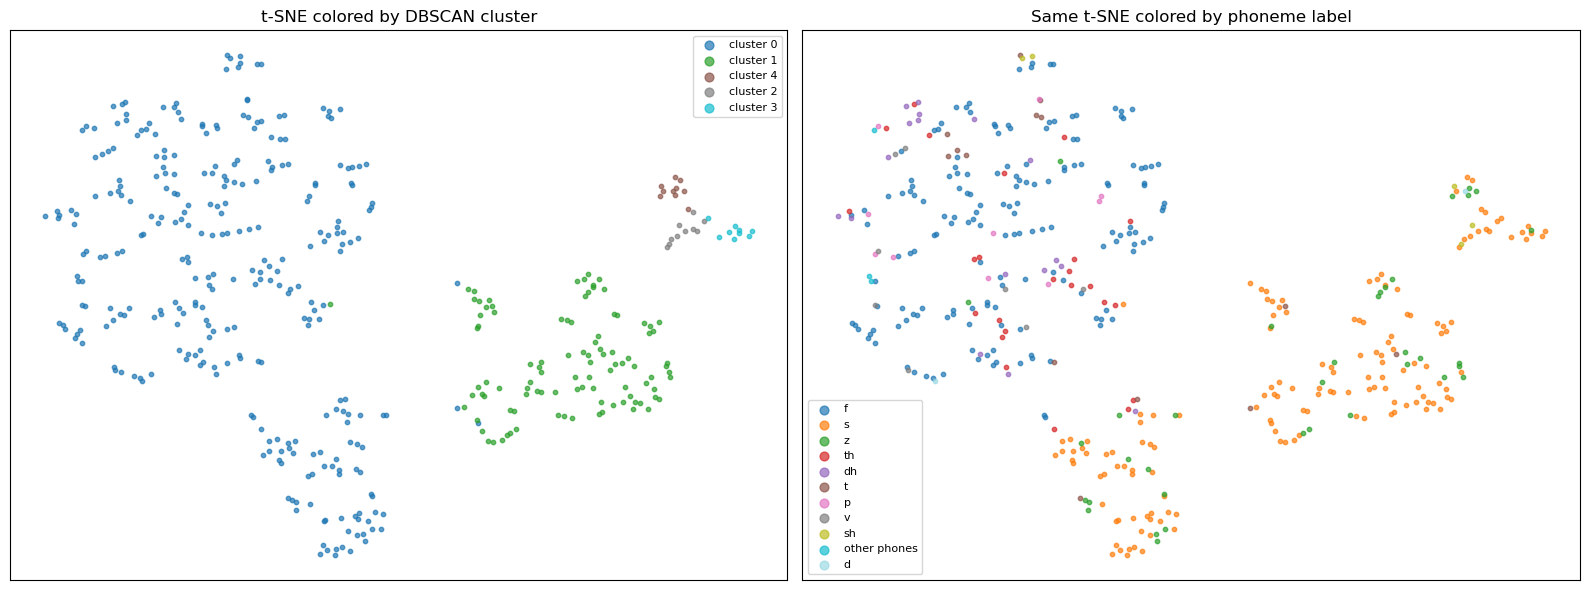

In [9]:
viz_pool = np.where(clustered_mask)[0] if clustered_mask.sum() > 0 else np.arange(len(X_sub_scaled))
viz_size = min(1200, len(viz_pool))
viz_idx = rng.choice(viz_pool, size=viz_size, replace=False)

tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    method="exact",
    perplexity=min(30, max(5, viz_size // 100)),
    random_state=0,
)
X_tsne = tsne.fit_transform(X_sub_scaled[viz_idx])

cluster_viz = cluster_labels[viz_idx]
phone_viz = y_sub[viz_idx]

cluster_counts = pd.Series(cluster_viz).value_counts()
top_cluster_ids = [cid for cid in cluster_counts.index if cid != -1][:8]
cluster_names = np.array([
    "noise" if cid == -1 else (f"cluster {cid}" if cid in top_cluster_ids else "other clusters")
    for cid in cluster_viz
])

phone_counts = pd.Series(phone_viz).value_counts()
top_phone_labels = list(phone_counts.index[:10])
phone_names = np.array([
    label if label in top_phone_labels else "other phones"
    for label in phone_viz
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_categories = list(pd.Series(cluster_names).value_counts().index)
cluster_cmap = plt.get_cmap("tab10", max(len(cluster_categories), 1))
for i, category in enumerate(cluster_categories):
    mask = cluster_names == category
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=10, alpha=0.7, color=cluster_cmap(i), label=category)
axes[0].set_title("t-SNE colored by DBSCAN cluster")
axes[0].legend(markerscale=2, fontsize=8)

phone_categories = list(pd.Series(phone_names).value_counts().index)
phone_cmap = plt.get_cmap("tab20", max(len(phone_categories), 1))
for i, category in enumerate(phone_categories):
    mask = phone_names == category
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=10, alpha=0.7, color=phone_cmap(i), label=category)
axes[1].set_title("Same t-SNE colored by phoneme label")
axes[1].legend(markerscale=2, fontsize=8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()
